In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
rf_iloco = pd.read_csv("/Users/mariahloehr/IICD/IICD/LOCO/iLOCO/iloco_decisionTree.csv")
df = pd.DataFrame(rf_iloco)

In [4]:
df

,feature,scores,ci
0,E2F1..nuc.median. & cycA..nuc.median.,-0.006262,0.024782
1,E2F1..nuc.median. & cycD1..nuc.median.,0.002989,0.024782
2,E2F1..nuc.median. & p21..nuc.median.,0.008364,0.024782
3,E2F1..nuc.median. & Int_Intg_DNA_nuc,0.014850,0.024782
4,E2F1..nuc.median. & Skp2..nuc.median.,-0.002867,0.024782
...,...,...,...
34186,CDK2_cyto_over_nuc & Local.cell.density,-0.005729,0.014275
34187,CDK2_cyto_over_nuc & ratio,-0.011693,0.014275
34188,STAT3..phospho.total.nuc. & Local.cell.density,0.001149,0.016657
34189,STAT3..phospho.total.nuc. & ratio,-0.002814,0.016657


In [11]:
import re

def rename_feature(name):
    # Pattern for matching each feature of the form Protein..loc.metric.
    pattern = r"(\w+)\.\.(nuc|cyto|PN|PM|cell)\.\w+\."

    def repl(match):
        protein, location = match.groups()
        location_map = {
            'nuc': 'nuc',
            'cyto': 'cyto',
            'PN': 'PN',
            'PM': 'PM',
            'cell': 'cell'
        }
        location_full = location_map.get(location, location)
        return f"{protein} ({location_full})"

    # Apply substitution to all matching parts of the string
    return re.sub(pattern, repl, name)

# Apply renaming
renamed_features = [rename_feature(col) for col in df["feature"]]

In [12]:
df["feature"] = renamed_features
top_20 = df.nlargest(10, "scores")
top_20.replace('p21 (nuc) & p38..phospho.total.PN.', 'p21 (nuc) & p38 phospho (PN)', inplace=True)
top_20.replace('ERK..phospho.total.cyto. & cycD1_over_p21', 'ERK phospho (cyto) & cycD1:p21', inplace=True)
top_20.replace('cFos (PM) & p38..phospho.total.PN.', 'cFos (PM) & p38 phospho (PN)', inplace=True)
top_20.replace('YAP (PN) & RB..phospho.total.cell.', 'YAP (PN) & RB phospho (cell)', inplace=True)

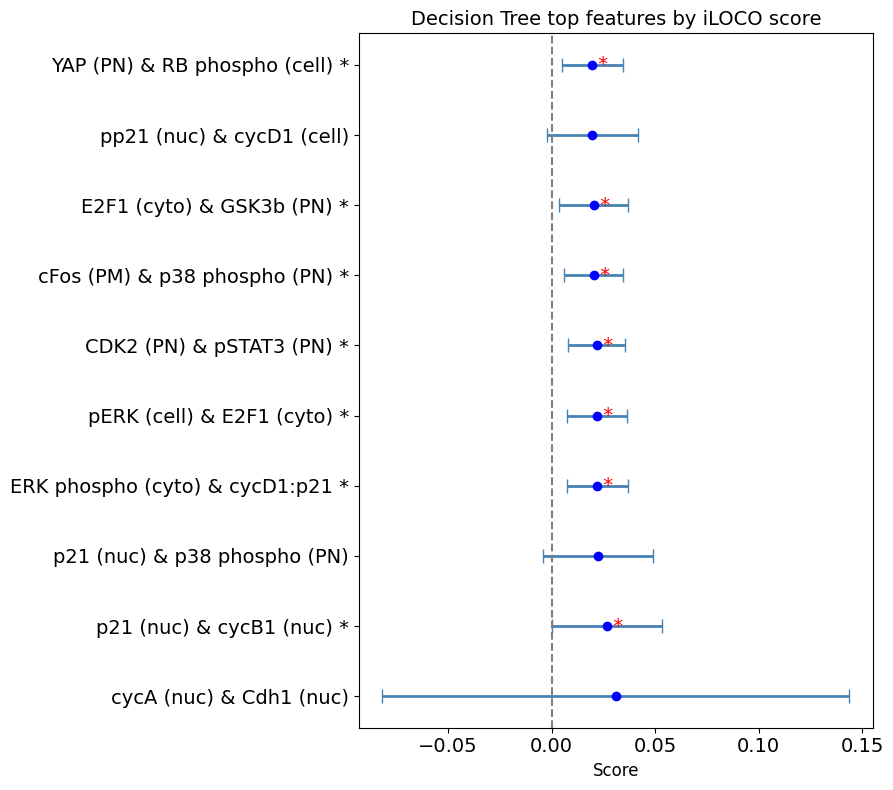

In [13]:
# Plot
# Copy feature names so we can modify them without affecting the original DataFrame
ytick_labels = top_20["feature"].copy()

# Add star next to feature names if CI does not include zero
for i, (score, ci) in enumerate(zip(top_20["scores"], top_20["ci"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:
        ytick_labels.iloc[i] += " *"

plt.figure(figsize=(9, 8))
plt.errorbar(
    top_20["scores"],
    top_20["feature"],
    xerr=top_20["ci"],
    fmt='o',  # Point marker
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)
plt.axvline(x=0, color='gray', linestyle='--')
plt.xticks(fontsize=14)  # Rotate x-axis labels vertically
plt.xlabel("Score", fontsize=12)
plt.title("Decision Tree top features by iLOCO score", fontsize=14)

# Add stars for scores whose confidence intervals do not include 0
for i, (score, ci, feature) in enumerate(zip(top_20["scores"], top_20["ci"], top_20["feature"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:  # CI does not include 0
        plt.text(score, feature, " *", color='red', fontsize=14, va='center')

plt.yticks(ticks=top_20["feature"], labels=ytick_labels, fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
df["feature"] = renamed_features
bottom = df.nsmallest(10, "scores")
#top_20.replace('p21 (nuc) & p38..phospho.total.PN.', 'p21 (nuc) & p38 phospho (PN)', inplace=True)
#top_20.replace('ERK..phospho.total.cyto. & cycD1_over_p21', 'ERK phospho (cyto) & cycD1:p21', inplace=True)
#top_20.replace('cFos (PM) & p38..phospho.total.PN.', 'cFos (PM) & p38 phospho (PN)', inplace=True)
#top_20.replace('YAP (PN) & RB..phospho.total.cell.', 'YAP (PN) & RB phospho (cell)', inplace=True)

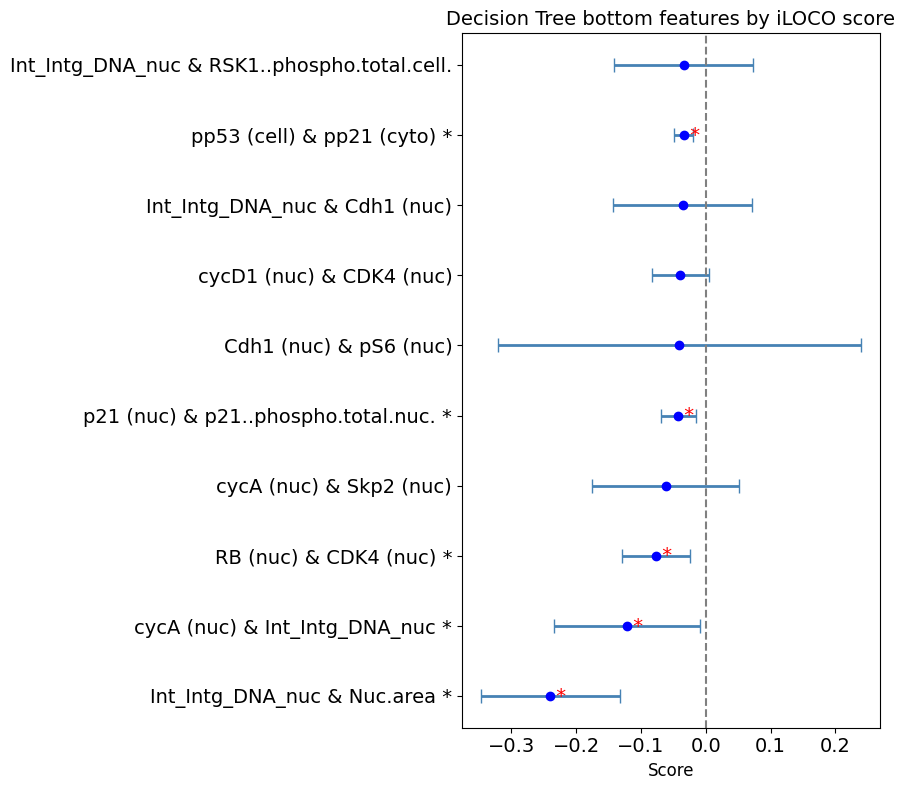

In [15]:
# Plot
ytick_labels = bottom["feature"].copy()

# Add star next to feature names if CI does not include zero
for i, (score, ci) in enumerate(zip(bottom["scores"], bottom["ci"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:
        ytick_labels.iloc[i] += " *"

plt.figure(figsize=(9, 8))
plt.errorbar(
    bottom["scores"],
    bottom["feature"],
    xerr=bottom["ci"],
    fmt='o',  # Point marker
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)

# Add stars for scores whose confidence intervals do not include 0
for i, (score, ci, feature) in enumerate(zip(bottom["scores"], bottom["ci"], bottom["feature"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:  # CI does not include 0
        plt.text(score, feature, " *", color='red', fontsize=14, va='center')

plt.axvline(x=0, color='gray', linestyle='--')
plt.yticks(ticks=bottom["feature"], labels=ytick_labels, fontsize=14)
plt.xticks(fontsize=14)  
plt.xlabel("Score", fontsize=12)
plt.title("Decision Tree bottom features by iLOCO score", fontsize=14)
plt.tight_layout()  # Ensure everything fits nicely
plt.show()

XGB

In [16]:
xgb_iloco = pd.read_csv("/Users/mariahloehr/IICD/IICD/LOCO/iLOCO/iloco_xgb.csv")
xgb_df = pd.DataFrame(xgb_iloco)

In [17]:
renamed_features = [rename_feature(col) for col in xgb_df["feature"]]

In [18]:
xgb_df["feature"] = renamed_features
top_20_xgb = xgb_df.nlargest(10, "scores")
top_20_xgb.replace('Cdh1 (PM) & p21..phospho.total.cell.', 'Cdh1 (PM) & p21 phospho (cell)', inplace=True)
top_20_xgb.replace('cycA (PN) & GSK3b..phospho.total.cyto.', 'Cdh1 (PM) & GSK3b phospho (cyto)', inplace=True)
top_20_xgb.replace('Int_Intg_DNA_nuc & YAP (cell)', 'DNA (nuc) & YAP (cell)', inplace=True)

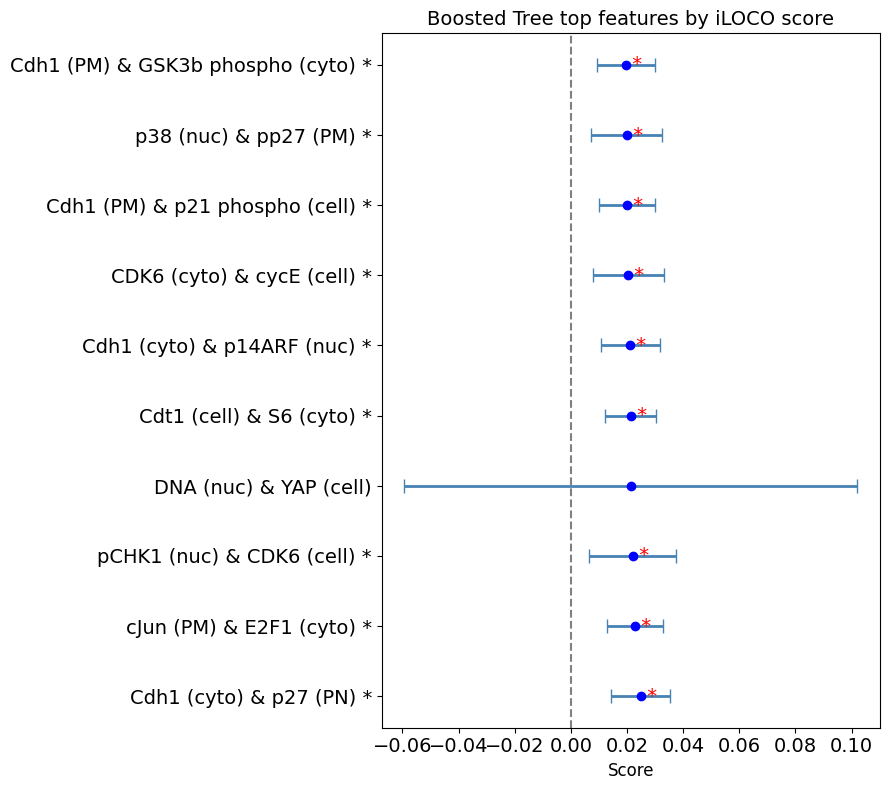

In [19]:
# Plot
ytick_labels = top_20_xgb["feature"].copy()

# Add star next to feature names if CI does not include zero
for i, (score, ci) in enumerate(zip(top_20_xgb["scores"], top_20_xgb["ci"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:
        ytick_labels.iloc[i] += " *"

plt.figure(figsize=(9, 8))
plt.errorbar(
    top_20_xgb["scores"],
    top_20_xgb["feature"],
    xerr=top_20_xgb["ci"],
    fmt='o',  # Point marker
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)

# Add stars for scores whose confidence intervals do not include 0
for i, (score, ci, feature) in enumerate(zip(top_20_xgb["scores"], top_20_xgb["ci"], top_20_xgb["feature"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:  # CI does not include 0
        plt.text(score, feature, " *", color='red', fontsize=14, va='center')

plt.axvline(x = 0, color = 'gray', linestyle = '--')
plt.xticks(fontsize=14)  
plt.yticks(ticks=top_20_xgb["feature"], labels=ytick_labels, fontsize=14)
plt.xlabel("Score", fontsize=12)
plt.title("Boosted Tree top features by iLOCO score", fontsize=14)
plt.tight_layout()  # Ensure everything fits nicely
plt.show()

In [20]:
xgb_df["feature"] = renamed_features
bottom = xgb_df.nsmallest(10, "scores")

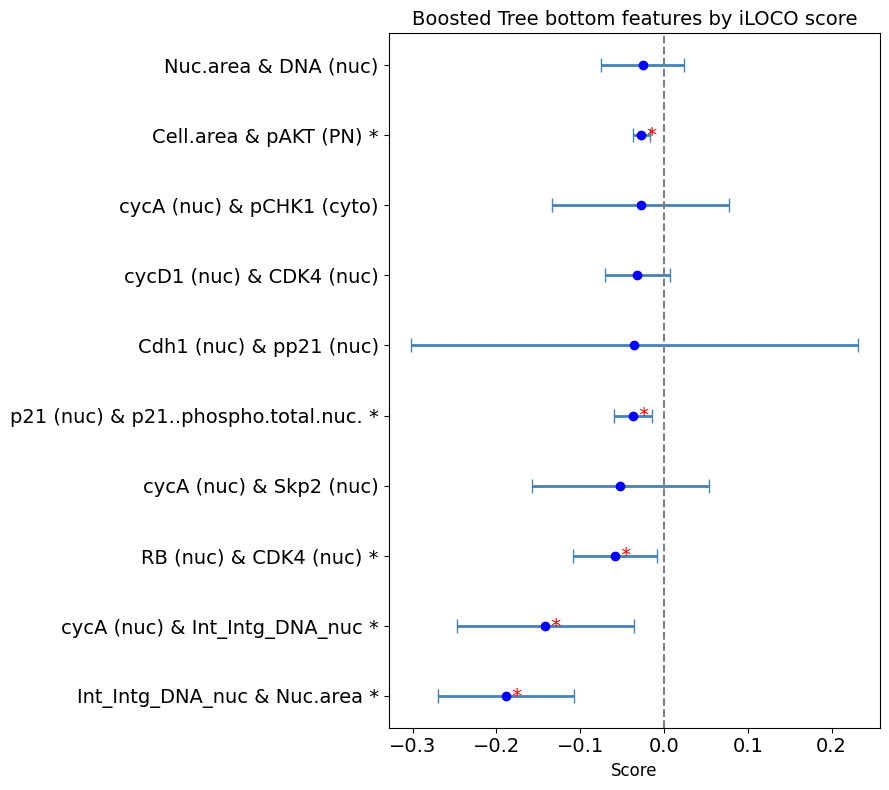

In [21]:
# Plot
ytick_labels = bottom["feature"].copy()

# Add star next to feature names if CI does not include zero
for i, (score, ci) in enumerate(zip(bottom["scores"], bottom["ci"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:
        ytick_labels.iloc[i] += " *"

plt.figure(figsize=(9, 8))
plt.errorbar(
    bottom["scores"],
    bottom["feature"],
    xerr=bottom["ci"],
    fmt='o',  # Point marker
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)

# Add stars for scores whose confidence intervals do not include 0
for i, (score, ci, feature) in enumerate(zip(bottom["scores"], bottom["ci"], bottom["feature"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:  # CI does not include 0
        plt.text(score, feature, " *", color='red', fontsize=14, va='center')

plt.axvline(x=0, color='gray', linestyle='--')
plt.yticks(ticks=bottom["feature"], labels=ytick_labels, fontsize=14)
plt.xticks(fontsize=14)  
plt.xlabel("Score", fontsize=12)
plt.title("Boosted Tree bottom features by iLOCO score", fontsize=14)
plt.tight_layout()  # Ensure everything fits nicely
plt.show()

MLP

In [22]:
mlp_iloco = pd.read_csv("/Users/mariahloehr/IICD/IICD/LOCO/iLOCO/iloco_mlp.csv")
mlp_df = pd.DataFrame(mlp_iloco)

In [23]:
renamed_features = [rename_feature(col) for col in mlp_df["feature"]]

In [24]:
mlp_df["feature"] = renamed_features
top_20_mlp = mlp_df.nlargest(10, "scores")
top_20_mlp.replace('RB (cell) & RB..phospho.total.nuc.', 'RB (cell) & RB phospho (nuc)', inplace=True)
top_20_mlp.replace('pAKT (cell) & STAT3..phospho.total.nuc.', 'pAKT (cell) & STAT phospho (nuc)', inplace=True)
#top_20_mlp.replace('cycA (PN) & GSK3b..phospho.total.cyto.', 'Cdh1 (PM) & GSK3b phospho (cyto)', inplace=True)
#top_20_mlp.replace('Int_Intg_DNA_nuc & YAP (cell)', 'DNA (nuc) & YAP (cell)', inplace=True)

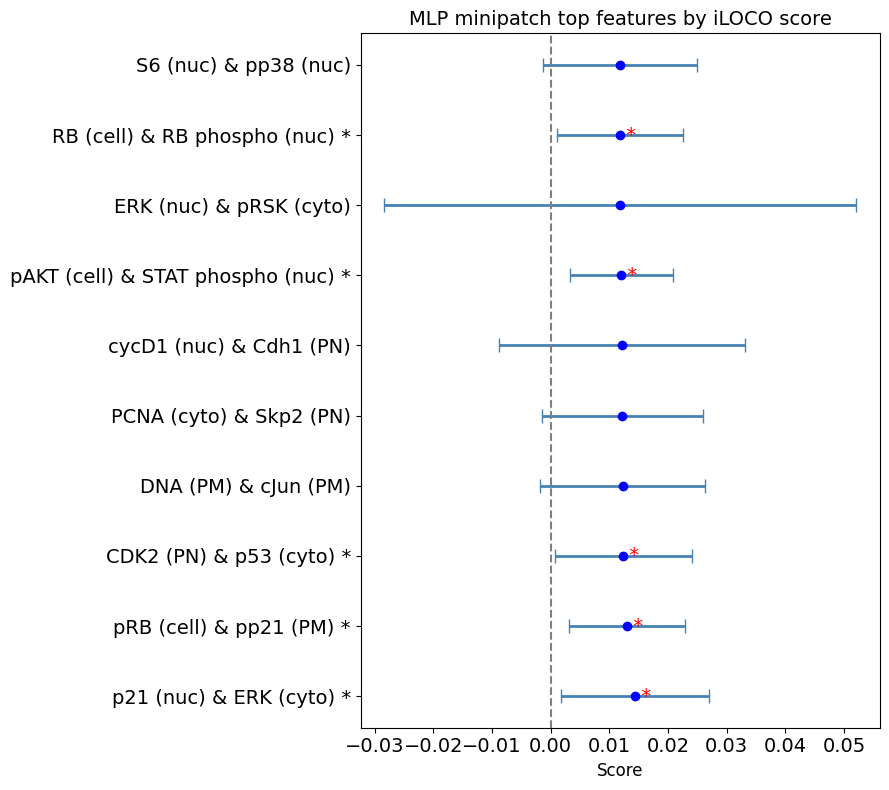

In [25]:
# Plot
ytick_labels = top_20_mlp["feature"].copy()

# Add star next to feature names if CI does not include zero
for i, (score, ci) in enumerate(zip(top_20_mlp["scores"], top_20_mlp["ci"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:
        ytick_labels.iloc[i] += " *"

plt.figure(figsize=(9, 8))
plt.errorbar(
    top_20_mlp["scores"],
    top_20_mlp["feature"],
    xerr=top_20_mlp["ci"],
    fmt='o',  # Point marker
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)
# Add stars for scores whose confidence intervals do not include 0
for i, (score, ci, feature) in enumerate(zip(top_20_mlp["scores"], top_20_mlp["ci"], top_20_mlp["feature"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:  # CI does not include 0
        plt.text(score, feature, " *", color='red', fontsize=14, va='center')

plt.axvline(x=0, color='gray', linestyle="--")
plt.yticks(ticks=top_20_mlp["feature"], labels=ytick_labels, fontsize=14)
plt.xticks(fontsize=14)
plt.xlabel("Score", fontsize=12)
plt.title("MLP minipatch top features by iLOCO score", fontsize=14)
plt.tight_layout()  # Ensure everything fits nicely
plt.show()

In [26]:
mlp_df["feature"] = renamed_features
bottom = mlp_df.nsmallest(10, "scores")

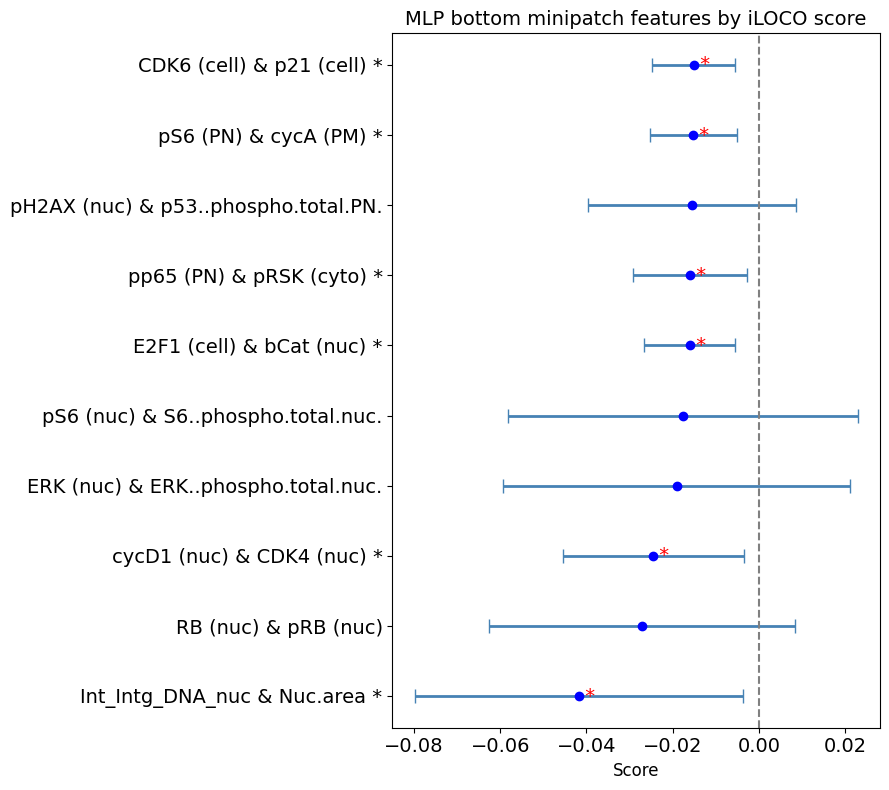

In [27]:
# Plot
ytick_labels = bottom["feature"].copy()

# Add star next to feature names if CI does not include zero
for i, (score, ci) in enumerate(zip(bottom["scores"], bottom["ci"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:
        ytick_labels.iloc[i] += " *"

plt.figure(figsize=(9, 8))
plt.errorbar(
    bottom["scores"],
    bottom["feature"],
    xerr=bottom["ci"],
    fmt='o',  # Point marker
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)

# Add stars for scores whose confidence intervals do not include 0
for i, (score, ci, feature) in enumerate(zip(bottom["scores"], bottom["ci"], bottom["feature"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:  # CI does not include 0
        plt.text(score, feature, " *", color='red', fontsize=14, va='center')

plt.axvline(x=0, color='gray', linestyle='--')
plt.yticks(ticks=bottom["feature"], labels=ytick_labels, fontsize=14)
plt.xticks(fontsize=14)  
plt.xlabel("Score", fontsize=12)
plt.title("MLP bottom minipatch features by iLOCO score", fontsize=14)
plt.tight_layout()  # Ensure everything fits nicely
plt.show()

COMBINED ILOCO SCORES

In [28]:
feature = rf_iloco[["feature"]]

df1_no_ref = rf_iloco.drop(columns="feature")
df2_no_ref = xgb_iloco.drop(columns="feature")
df3_no_ref = mlp_iloco.drop(columns="feature")

summed = df1_no_ref + df2_no_ref + df3_no_ref

merged = pd.concat([feature, summed], axis=1)

In [29]:
renamed_features = [rename_feature(col) for col in merged["feature"]]
merged["feature"] = renamed_features
top_20_merged = merged.nlargest(10, "scores")

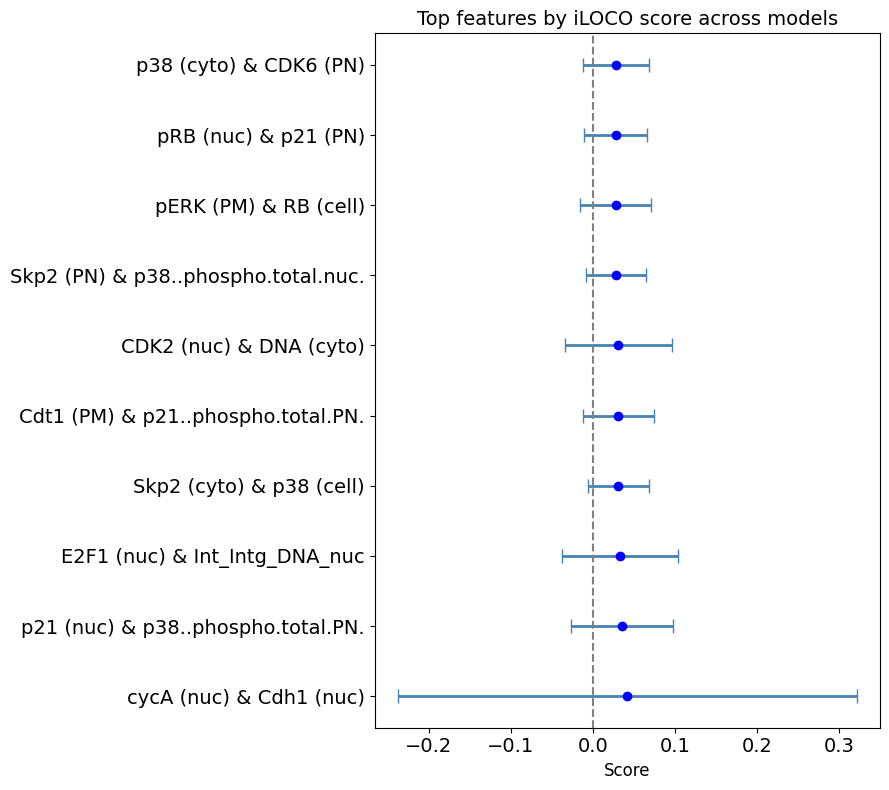

In [34]:
# Copy feature names
ytick_labels = top_20_merged["feature"].copy()

# Add star next to feature names if CI does not include zero
for i, (score, ci) in enumerate(zip(top_20_merged["scores"], top_20_merged["ci"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:  # Significant
        ytick_labels.iloc[i] += " *"

plt.figure(figsize=(9, 8))
plt.errorbar(
    top_20_merged["scores"],       # x = scores
    top_20_merged["feature"],      # y = feature names
    xerr=top_20_merged["ci"],      # CI as horizontal error bars
    fmt='o',                       # point marker
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)

# Add red stars next to significant points
for score, ci, feature in zip(top_20_merged["scores"], top_20_merged["ci"], top_20_merged["feature"]):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:  # Significant
        plt.text(score, feature, " ★", color='red', fontsize=14, va='center')

# Add zero reference line
plt.axvline(x=0, color='gray', linestyle="--")

# Formatting
plt.yticks(ticks=top_20_merged["feature"], labels=ytick_labels, fontsize=14)
plt.xticks(fontsize=14)
plt.xlabel("Score", fontsize=12)
plt.title("Top features by iLOCO score across models", fontsize=14)
plt.tight_layout()
plt.show()


In [31]:
bottom = merged.nsmallest(10, "scores")

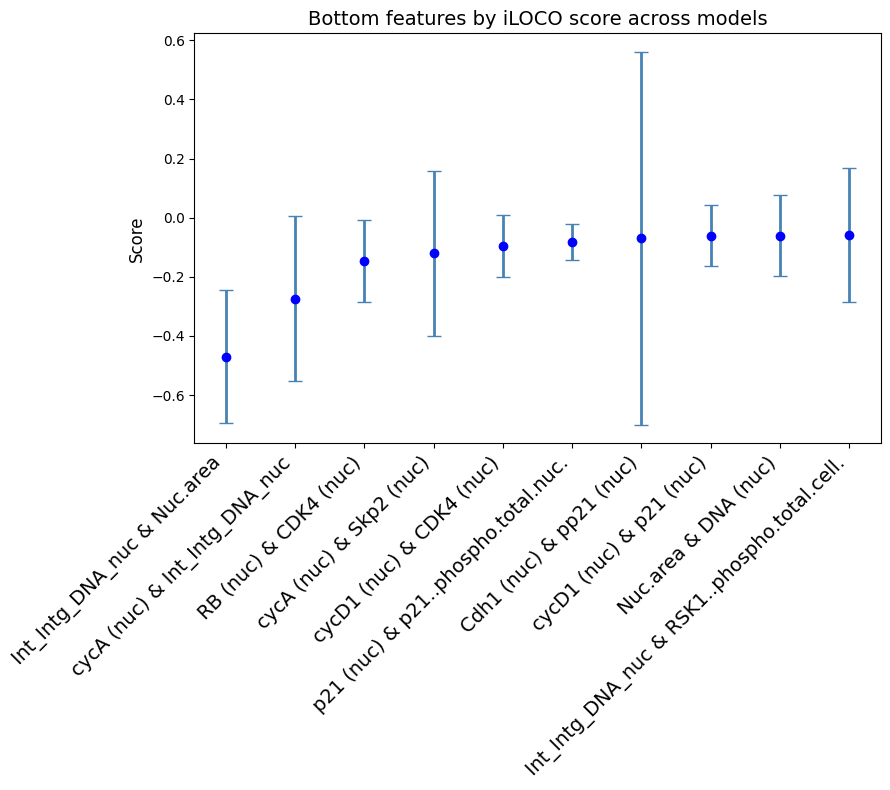

In [32]:
# Plot
plt.figure(figsize=(9, 8))
plt.errorbar(
    bottom["feature"],
    bottom["scores"],
    yerr=bottom["ci"],
    fmt='o',  # Point marker
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)
plt.xticks(rotation=45, fontsize=14, ha = "right")  # Rotate x-axis labels vertically
plt.ylabel("Score", fontsize=12)
plt.title("Bottom features by iLOCO score across models", fontsize=14)
plt.tight_layout()  # Ensure everything fits nicely
plt.show()

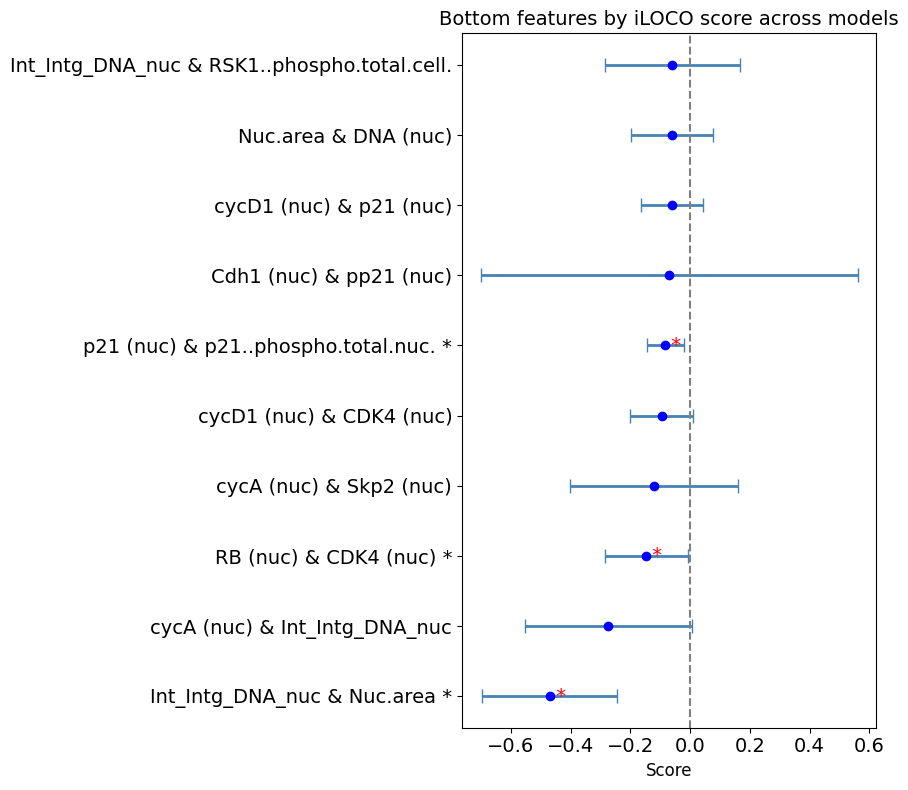

In [37]:
# Copy feature names
ytick_labels = bottom["feature"].copy()

# Add star next to feature names if CI does not include zero
for i, (score, ci) in enumerate(zip(bottom["scores"], bottom["ci"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:  # Significant
        ytick_labels.iloc[i] += " *"

plt.figure(figsize=(9, 8))
plt.errorbar(
    bottom["scores"],         # x = scores
    bottom["feature"],        # y = features
    xerr=bottom["ci"],        # CI as horizontal error bars
    fmt='o',
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)

# Add red stars next to significant points
for score, ci, feature in zip(bottom["scores"], bottom["ci"], bottom["feature"]):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:
        plt.text(score, feature, " *", color='red', fontsize=14, va='center')

# Add zero reference line
plt.axvline(x=0, color='gray', linestyle="--")

# Formatting
plt.yticks(ticks=bottom["feature"], labels=ytick_labels, fontsize=14)
plt.xticks(fontsize=14)
plt.xlabel("Score", fontsize=12)
plt.title("Bottom features by iLOCO score across models", fontsize=14)
plt.tight_layout()
plt.show()
